<a href="https://colab.research.google.com/github/gien-7/progetto_GraphColouring_ML26/blob/main/Notebook_GNN_v0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git'

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

La cartella 'progetto_GraphColouring_ML26' è già caricata


In [3]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

**Leggiamo i dati, controlliamo il formato (shape) e ne stampiamo la struttura**



In [4]:
import pandas as pd

file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


In [5]:
print(df_g6)

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


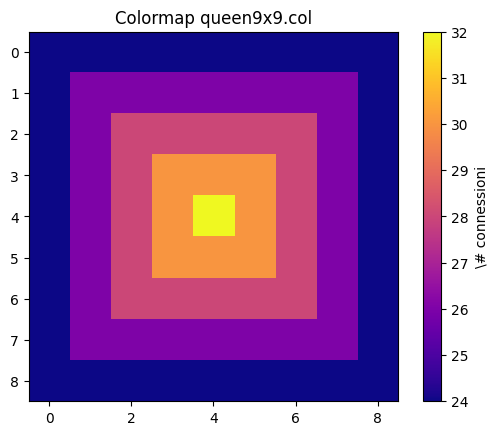

In [6]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
intensity = counts.reshape(9,9)

plt.imshow(intensity, cmap='plasma')
plt.colorbar(label = '\# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

In [7]:
np.stack(unique.reshape(9,9))

array([[ 1,  2,  3,  4,  5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24, 25, 26, 27],
       [28, 29, 30, 31, 32, 33, 34, 35, 36],
       [37, 38, 39, 40, 41, 42, 43, 44, 45],
       [46, 47, 48, 49, 50, 51, 52, 53, 54],
       [55, 56, 57, 58, 59, 60, 61, 62, 63],
       [64, 65, 66, 67, 68, 69, 70, 71, 72],
       [73, 74, 75, 76, 77, 78, 79, 80, 81]])

**Data augmentation sfruttando invarianze del problema**

In [8]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.utils.data as data

!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.4 MB/s eta 0:00:00


In [9]:
#GraphGenerator(intensity), label = color, connessioni da g6.col

In [10]:
from torch_geometric.loader import DataLoader
import torch_geometric.data as Data

class GraphGenerator(Dataset):  # Cambiamento rispetto alla CNN: il Dataset ora produce grafi PyG, non immagini.
    def __init__(self, X, y):
        self.X = X  # dati (scacchiera)
        self.y = y  # indice di colore

    def __len__(self):  # Ritorna la dimensione del dataset
        return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      label = self.y[idx].copy()

      rows, cols = np.indices((9, 9))
      rows = rows.flatten()
      cols = cols.flatten()
      values = intensity[rows, cols].astype(np.float32)

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float)
      pos_n = (pos/8)*2 - 1
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1)
      x = torch.cat([value, pos], dim=1)

      # Il grafo è costruito con k=4 vicini più prossimi degli hit.
      '''edge_index = build_knn_edges(pos, k=self.k)'''
      '''Capire bene la forma dell'edge_index'''

      # Manteniamo la label one-hot come nel notebook CNN; PyG concatenerà queste righe nella batch.
      tensor_color = torch.from_numpy(label).float().view(1, -1)

      return Data(x=x, edge_index=edge_index, y=tensor_color, pos=pos_n)


In [13]:
#MODIFICARE, CONTESTO DI GRAPH AUGMENTATION

def RotateGraph(graph, theta):
    return np.rot90(graph, k=theta)

def FlipHorizontalGraph(graph):
    return np.fliplr(graph)

def FlipVerticalGraph(graph):
    return np.flipud(graph)

def TransposeGraph(graph):
    return np.transpose(graph)

**Splitting del dataset**

In [12]:
from sklearn.model_selection import train_test_split

X, X_val, y, y_val = train_test_split(x_all, y_all, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

print('Shape X_train : ',X.shape)
print('Shape X_val   : ',X_val.shape)
print('Shape X_test  : ',X_test.shape)

NameError: name 'x_all' is not defined